In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support

In [152]:
# Preprocesses the data into pandas dataframes which then can be read easier
def preprocessEmotionData(df):
    # Only takes the items "text" and "label" from each entry in the csv
    df = df[["text", "label"]]
    # Drops the entry from the dataframe if the there is no "text" or "label"
    df = df.dropna(subset=["text", "label"])
    # Fills NaN values in "text" with ""
    df["text"] = df["text"].fillna("")
    return df

In [153]:
def showLabelDistribution(df_new, emotionLabelDict):
    # Counts how many times each label occurs in the data
    label_counts = df_new['label'].value_counts().sort_index()

    # Prints the label counts with emotion names
    print("\nLabel Distribution After Preprocessing:")
    for i, j in label_counts.items():
        print(str(i) + " (" + emotionLabelDict.get(i) + "): " + str(j))

    # Shows the label counts graphically
    plt.figure(figsize=(10, 6))
    x_axis_labels = []
    for i in label_counts.index:
        x_axis_labels.append(str(i) + " (" + emotionLabelDict.get(i) + ")")
    plt.bar(x_axis_labels, label_counts.values, color = 'blue')
    plt.title("Label Distribution After Preprocessing")
    plt.xlabel("Label (Emotion)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


In [154]:
# Trains data and determines metrics
def getMetrics(df, oversampling, k, emotionLabelDict):
    # Lists to store metrics over each of the folds
    accuracyMetrics = []
    precisionMetrics = []
    recallMetrics = []
    f1Metrics = []
    # Dictionary to store metrics for each label
    metricsPerLabelandKFold = dict()
    for i in emotionLabelDict.keys():
        metricsPerLabelandKFold[i] = {"precision": [], "recall": [], "f1Score": []}
    metricsPerLabel = dict()
    # Defines Kfolds with and a constant "randomness" and shuffling
    kFolds = KFold(n_splits = k, random_state = 1, shuffle = True)
    # Loop through each fold
    for i, j in kFolds.split(df):
        # Splits up the data
        trainingSet = df.iloc[i]
        testingSet = df.iloc[j]
        # Converts the information into TF-IDF features
        # Max features are 5000 because 10000 takes too long
        # ngram range(1,2) is used because this allows for unigrams and bigrams
        # stop_words = "english" removes words like "is", "and", "the" because they are just noise
        vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 2), stop_words = "english")
        trainTFIDF = vectorizer.fit_transform(trainingSet["text"])
        testTFIDF = vectorizer.transform(testingSet["text"])
        if oversampling == True:
            # Creates OverSampler and uses it to oversample under sampled labels
            ros = RandomOverSampler(random_state = 1)
            X_resampled, y_resampled = ros.fit_resample(trainTFIDF, trainingSet["label"])
            # Naive Bayes Classifier used:
            classifier = MultinomialNB()
            # Trains and classifier and predicts test data
            classifier.fit(X_resampled, y_resampled)
        else:
            # Naive Bayes Classifier used:
            classifier = MultinomialNB()
            # Trains and classifier and predicts test data
            classifier.fit(trainTFIDF, trainingSet["label"])
        prediction = classifier.predict(testTFIDF)
        # Finds requested metrics and adds to their corresponding lists (multiplied by 100 so they can be displayed as % later on)
        accuracyMetrics.append(accuracy_score(testingSet["label"], prediction) * 100)
        precisionMetrics.append(precision_score(testingSet["label"], prediction, average='macro') * 100)
        recallMetrics.append(recall_score(testingSet["label"], prediction, average='macro') * 100)
        f1Metrics.append(f1_score(testingSet["label"], prediction, average='macro') * 100)
        # Provides the metrics for each label in the k fold
        prec, rec, f1, _ = precision_recall_fscore_support(testingSet["label"], prediction, labels = list(emotionLabelDict.keys()), zero_division = 0)
        # Adds each per label metric to the dictionary
        for k, l in enumerate(emotionLabelDict.keys()):
            metricsPerLabelandKFold[l]["precision"].append(prec[k] * 100)
            metricsPerLabelandKFold[l]["recall"].append(rec[k] * 100)
            metricsPerLabelandKFold[l]["f1Score"].append(f1[k] * 100)
        # Add averages for each per label metric to the dictionary
        # Add averages for each per label metric to the dictionary
        for k in metricsPerLabelandKFold.keys():
            metricsPerLabel[k] = {
                "precision": np.mean(metricsPerLabelandKFold[k]["precision"]),
                "recall": np.mean(metricsPerLabelandKFold[k]["recall"]),
                "f1Score": np.mean(metricsPerLabelandKFold[k]["f1Score"])
            }
    return [
        accuracyMetrics, np.mean(accuracyMetrics),
        precisionMetrics, np.mean(precisionMetrics),
        recallMetrics, np.mean(recallMetrics),
        f1Metrics, np.mean(f1Metrics)
    ], metricsPerLabel

In [155]:
def plot_overall_metrics(classifier, kFolds, metrics, oversampling):
    # Metrics
    accuracyData = metrics[0]
    accuracyAvg = metrics[1]
    precisionData = metrics[2]
    precisionAvg = metrics[3]
    recallData = metrics[4]
    recallAvg = metrics[5]
    f1Data = metrics[6]
    f1Avg = metrics[7]
    # Indices of the k folds
    x = np.arange(len(kFolds))
    # Creating the figure
    plt.figure(figsize=(10, 6))
    plt.title(f"All Metrics Across {len(kFolds)} K-Folds for {classifier} and Oversampling = {str(oversampling)}")
    plt.xlabel("K-Fold Iteration")
    plt.ylabel("Metric (%)")
    plt.ylim(0, 100)
    plt.xticks(x, kFolds)
    # Plot the bars in the right orientation
    plt.bar(x - 1.5 * 0.2, accuracyData, 0.2, label = "Accuracy")
    plt.bar(x - 0.5 * 0.2, precisionData, 0.2, label = "Precision")
    plt.bar(x + 0.5 * 0.2, recallData, 0.2, label = "Recall")
    plt.bar(x + 1.5 * 0.2, f1Data, 0.2, label = "F1 Score")
    # Add averages for each metric
    plt.axhline(y = accuracyAvg, color = "blue", linestyle = "--", linewidth = 1)
    plt.axhline(y = precisionAvg, color = "orange", linestyle = "--", linewidth = 1)
    plt.axhline(y = recallAvg, color = "green", linestyle = "--", linewidth = 1)
    plt.axhline(y = f1Avg, color = "red", linestyle = "--", linewidth = 1)
    plt.legend()
    plt.tight_layout()
    plt.show()
    # Print out values numerically
    for i in range(len(kFolds)):
        print("K-Fold " + str(kFolds[i]) + ":")
        print("  Accuracy:  " + f"{accuracyData[i]:.2f}" + "%")
        print("  Precision: " + f"{precisionData[i]:.2f}" + "%")
        print("  Recall:    " + f"{recallData[i]:.2f}" + "%")
        print("  F1 Score:  " + f"{f1Data[i]:.2f}" + "%\n")
    print("Averages Across All Folds:")
    print("  Accuracy:  " + f"{accuracyAvg:.2f}" + "%")
    print("  Precision: " + f"{precisionAvg:.2f}" + "%")
    print("  Recall:    " + f"{recallAvg:.2f}" + "%")
    print("  F1 Score:  " + f"{f1Avg:.2f}" + "%\n")

In [156]:
def plot_metric_per_label(classifier, metrics, oversampling, emotionLabelDict):
    # Metrics
    precision_vals = []
    recall_vals = []
    f1_vals = []
    x_labels = []
    labels = list(emotionLabelDict.keys())
    for i in labels:
        precision_vals.append(metrics[i]["precision"])
        recall_vals.append(metrics[i]["recall"])
        f1_vals.append(metrics[i]["f1Score"])
        x_labels.append(str(i) + " (" + emotionLabelDict[i] + ")")
    # Indices of the k folds
    x = np.arange(len(labels))
    # Create the figure
    plt.figure(figsize=(10, 6))
    plt.title(f"Per-Label Average Metrics for {classifier} and Oversampling = {str(oversampling)}")
    plt.xlabel("Label (Emotion)")
    plt.ylabel("Metric (%)")
    plt.ylim(0, 100)
    plt.xticks(x, x_labels)
    # Plot the bars in the right orientation
    plt.bar(x - 0.25, precision_vals, width = 0.25, label = "Precision")
    plt.bar(x, recall_vals, width = 0.25, label = "Recall")
    plt.bar(x + 0.25, f1_vals, width = 0.25, label = "F1 Score")
    plt.legend()
    plt.tight_layout()
    plt.show()
    # Print values numerically
    print("Average Metrics Per Label:\n")
    for i, label in enumerate(labels):
        print(str(label) + " (" + emotionLabelDict[label] + "):")
        print("  Precision: " + f"{precision_vals[i]:.2f}" + "%")
        print("  Recall:    " + f"{recall_vals[i]:.2f}" + "%")
        print("  F1 Score:  " + f"{f1_vals[i]:.2f}" + "%\n")



Label Distribution After Preprocessing:
0 (sadness): 121187
1 (joy): 141067
2 (love): 34554
3 (anger): 57317
4 (fear): 47712
5 (surprise): 14972


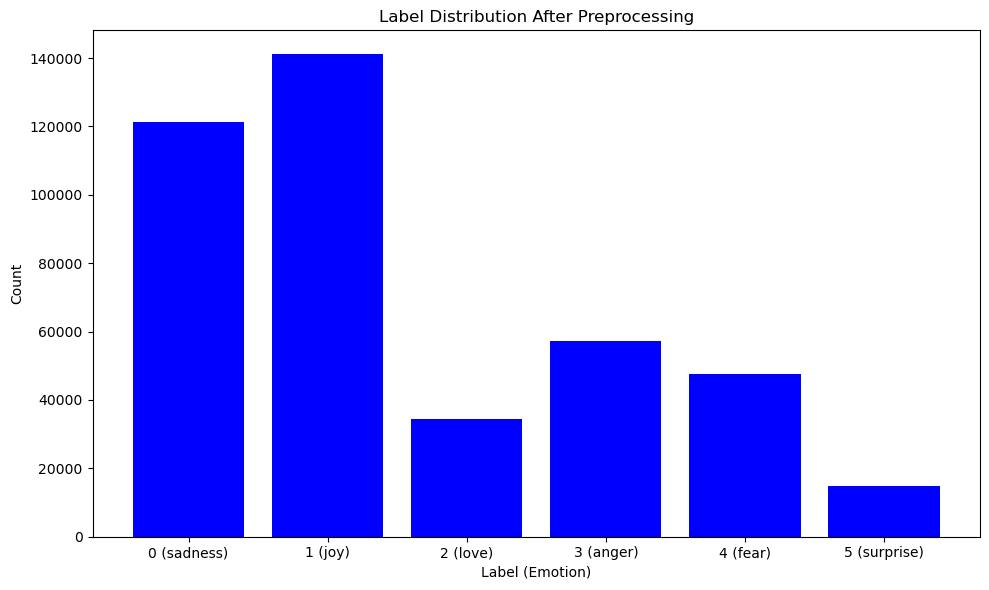

In [157]:
# Running/Obtaining output from HW3 dataset
df = pd.read_csv("text.csv")
df_new = preprocessEmotionData(df)
# Shows which emotion correlates to each label
emotionLabelDict = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}
# Shows the label distribution of each label
showLabelDistribution(df_new, emotionLabelDict)
k = 5 # Number of folds
kFolds = list(range(1, k + 1))

In [158]:
# Running with oversampling as false
oversampling = False
NB_metrics, NBMetricsPerLabel = getMetrics(df_new, oversampling, k, emotionLabelDict)

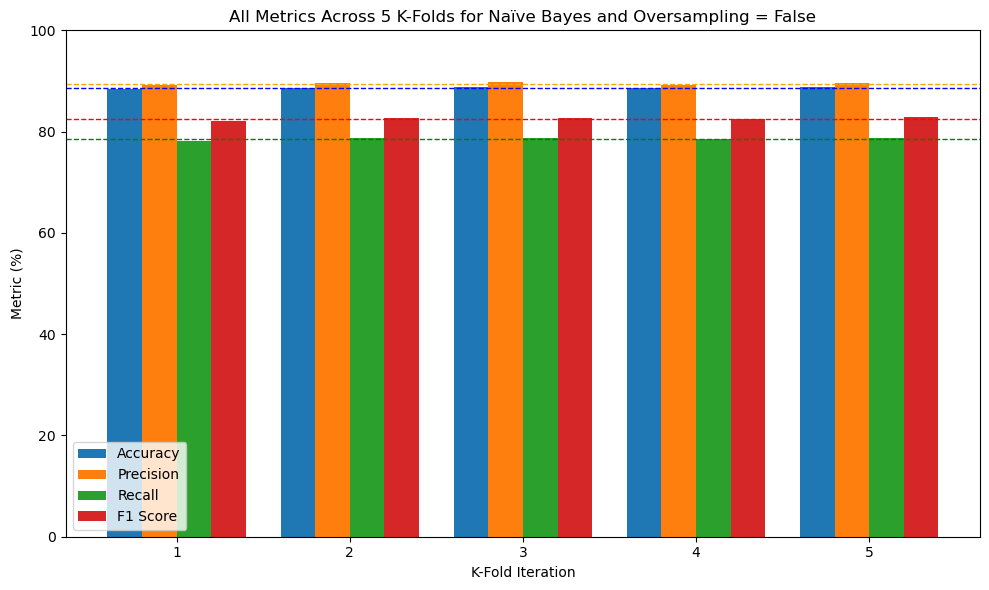

K-Fold 1:
  Accuracy:  88.34%
  Precision: 89.14%
  Recall:    78.15%
  F1 Score:  82.12%

K-Fold 2:
  Accuracy:  88.66%
  Precision: 89.51%
  Recall:    78.81%
  F1 Score:  82.76%

K-Fold 3:
  Accuracy:  88.77%
  Precision: 89.73%
  Recall:    78.73%
  F1 Score:  82.74%

K-Fold 4:
  Accuracy:  88.62%
  Precision: 89.20%
  Recall:    78.48%
  F1 Score:  82.42%

K-Fold 5:
  Accuracy:  88.76%
  Precision: 89.60%
  Recall:    78.83%
  F1 Score:  82.80%

Averages Across All Folds:
  Accuracy:  88.63%
  Precision: 89.44%
  Recall:    78.60%
  F1 Score:  82.57%



In [159]:
# Show overall model metrics over all kfolds (and the averages)
plot_overall_metrics("Naïve Bayes", kFolds, NB_metrics, oversampling)

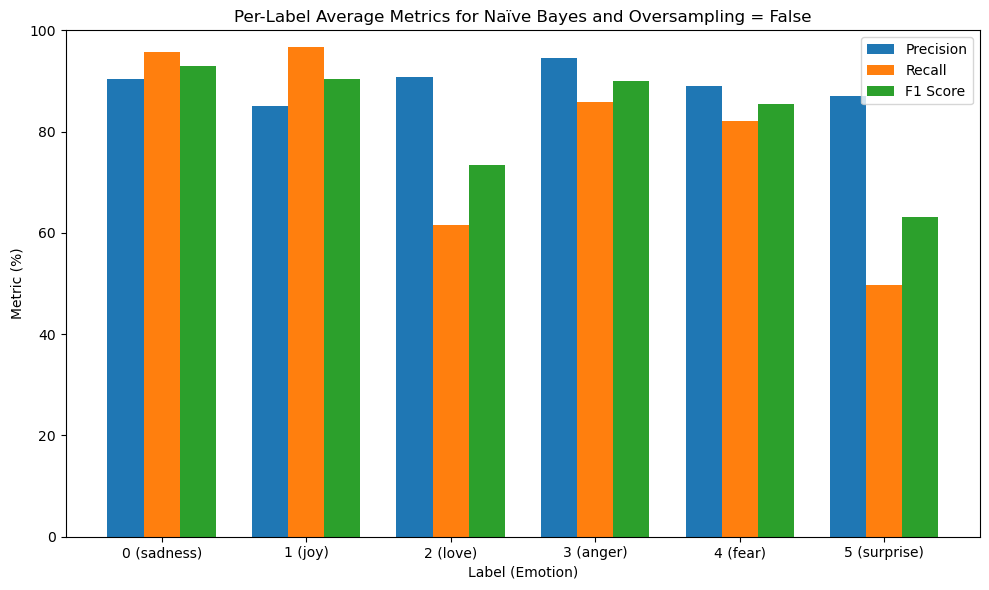

Average Metrics Per Label:

0 (sadness):
  Precision: 90.36%
  Recall:    95.64%
  F1 Score:  92.92%

1 (joy):
  Precision: 85.01%
  Recall:    96.67%
  F1 Score:  90.47%

2 (love):
  Precision: 90.76%
  Recall:    61.66%
  F1 Score:  73.43%

3 (anger):
  Precision: 94.47%
  Recall:    85.94%
  F1 Score:  90.00%

4 (fear):
  Precision: 89.06%
  Recall:    82.05%
  F1 Score:  85.41%

5 (surprise):
  Precision: 86.96%
  Recall:    49.64%
  F1 Score:  63.19%



In [160]:
# Show the average metric per label
plot_metric_per_label("Naïve Bayes", NBMetricsPerLabel, oversampling, emotionLabelDict)

In [161]:
# Running with oversampling as True
oversampling = True
NB_metrics, NBMetricsPerLabel = getMetrics(df_new, oversampling, k, emotionLabelDict)

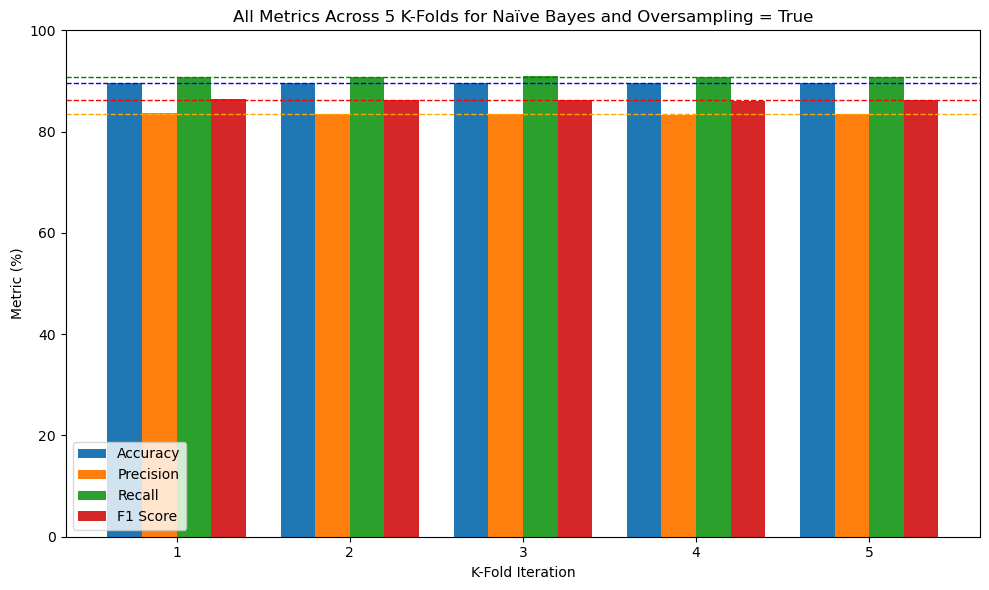

K-Fold 1:
  Accuracy:  89.64%
  Precision: 83.66%
  Recall:    90.85%
  F1 Score:  86.34%

K-Fold 2:
  Accuracy:  89.55%
  Precision: 83.55%
  Recall:    90.84%
  F1 Score:  86.28%

K-Fold 3:
  Accuracy:  89.54%
  Precision: 83.43%
  Recall:    90.91%
  F1 Score:  86.21%

K-Fold 4:
  Accuracy:  89.55%
  Precision: 83.33%
  Recall:    90.85%
  F1 Score:  86.11%

K-Fold 5:
  Accuracy:  89.60%
  Precision: 83.51%
  Recall:    90.88%
  F1 Score:  86.21%

Averages Across All Folds:
  Accuracy:  89.58%
  Precision: 83.49%
  Recall:    90.87%
  F1 Score:  86.23%



In [162]:
# Show overall model metrics over all kfolds (and the averages)
plot_overall_metrics("Naïve Bayes", kFolds, NB_metrics, oversampling)

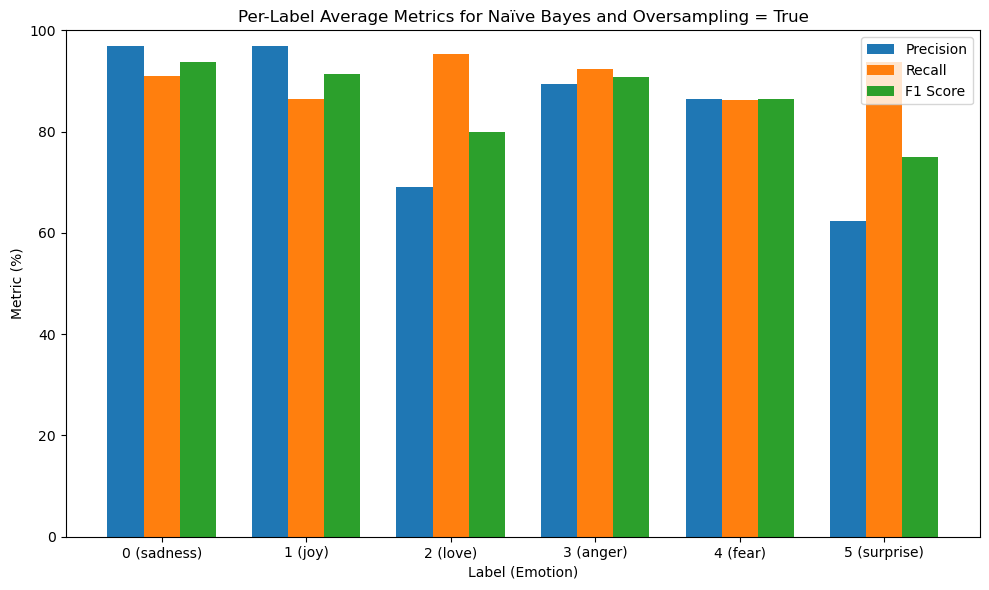

Average Metrics Per Label:

0 (sadness):
  Precision: 96.82%
  Recall:    91.02%
  F1 Score:  93.83%

1 (joy):
  Precision: 96.98%
  Recall:    86.48%
  F1 Score:  91.43%

2 (love):
  Precision: 68.97%
  Recall:    95.29%
  F1 Score:  80.02%

3 (anger):
  Precision: 89.34%
  Recall:    92.34%
  F1 Score:  90.81%

4 (fear):
  Precision: 86.51%
  Recall:    86.30%
  F1 Score:  86.41%

5 (surprise):
  Precision: 62.34%
  Recall:    93.78%
  F1 Score:  74.89%



In [163]:
# Show the average metric per label
plot_metric_per_label("Naïve Bayes", NBMetricsPerLabel, oversampling, emotionLabelDict)